<a href="https://www.kaggle.com/code/lalit7881/superstore-sales-insights?scriptVersionId=301913509" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/thuandao/superstore-sales-analytics/SuperStoreOrders - SuperStoreOrders.csv


## Import dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/thuandao/superstore-sales-analytics/SuperStoreOrders - SuperStoreOrders.csv")

In [3]:
df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,1/1/2011,5/1/2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,1/1/2011,5/1/2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011


In [4]:
df.tail()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
51285,CA-2014-115427,31/12/2014,4/1/2015,Standard Class,Erica Bern,Corporate,California,United States,US,West,...,Office Supplies,Binders,"Cardinal Slant-D Ring Binder, Heavy Gauge Vinyl",14,2,0.2,4.5188,0.89,Medium,2014
51286,MO-2014-2560,31/12/2014,5/1/2015,Standard Class,Liz Preis,Consumer,Souss-Massa-Draâ,Morocco,Africa,Africa,...,Office Supplies,Binders,"Wilson Jones Hole Reinforcements, Clear",4,1,0.0,0.4200,0.49,Medium,2014
51287,MX-2014-110527,31/12/2014,2/1/2015,Second Class,Charlotte Melton,Consumer,Managua,Nicaragua,LATAM,Central,...,Office Supplies,Labels,"Hon Color Coded Labels, 5000 Label Set",26,3,0.0,12.3600,0.35,Medium,2014
51288,MX-2014-114783,31/12/2014,6/1/2015,Standard Class,Tamara Dahlen,Consumer,Chihuahua,Mexico,LATAM,North,...,Office Supplies,Labels,"Hon Legal Exhibit Labels, Alphabetical",7,1,0.0,0.5600,0.20,Medium,2014
51289,CA-2014-156720,31/12/2014,4/1/2015,Standard Class,Jill Matthias,Consumer,Colorado,United States,US,West,...,Office Supplies,Fasteners,Bagged Rubber Bands,3,3,0.2,-0.6048,0.17,Medium,2014


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        51290 non-null  object 
 1   order_date      51290 non-null  object 
 2   ship_date       51290 non-null  object 
 3   ship_mode       51290 non-null  object 
 4   customer_name   51290 non-null  object 
 5   segment         51290 non-null  object 
 6   state           51290 non-null  object 
 7   country         51290 non-null  object 
 8   market          51290 non-null  object 
 9   region          51290 non-null  object 
 10  product_id      51290 non-null  object 
 11  category        51290 non-null  object 
 12  sub_category    51290 non-null  object 
 13  product_name    51290 non-null  object 
 14  sales           51290 non-null  object 
 15  quantity        51290 non-null  int64  
 16  discount        51290 non-null  float64
 17  profit          51290 non-null 

In [6]:
df.describe()

,quantity,discount,profit,shipping_cost,year
count,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,3.476545,0.142908,28.641740,26.375915,2012.777208
std,2.278766,0.212280,174.424113,57.296804,1.098931
min,1.000000,0.000000,-6599.978000,0.000000,2011.000000
25%,2.000000,0.000000,0.000000,2.610000,2012.000000
50%,3.000000,0.000000,9.240000,7.790000,2013.000000
75%,5.000000,0.200000,36.810000,24.450000,2014.000000
max,14.000000,0.850000,8399.976000,933.570000,2014.000000


In [7]:
df.isnull().sum()

order_id          0
order_date        0
ship_date         0
ship_mode         0
customer_name     0
segment           0
state             0
country           0
market            0
region            0
product_id        0
category          0
sub_category      0
product_name      0
sales             0
quantity          0
discount          0
profit            0
shipping_cost     0
order_priority    0
year              0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

order_id           object
order_date         object
ship_date          object
ship_mode          object
customer_name      object
segment            object
state              object
country            object
market             object
region             object
product_id         object
category           object
sub_category       object
product_name       object
sales              object
quantity            int64
discount          float64
profit            float64
shipping_cost     float64
order_priority     object
year                int64
dtype: object

In [10]:
df.shape

(51290, 21)

In [11]:
df.columns

Index(['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_name',
       'segment', 'state', 'country', 'market', 'region', 'product_id',
       'category', 'sub_category', 'product_name', 'sales', 'quantity',
       'discount', 'profit', 'shipping_cost', 'order_priority', 'year'],
      dtype='object')

In [12]:
df.nunique()

order_id          25035
order_date         1430
ship_date          1464
ship_mode             4
customer_name       795
segment               3
state              1094
country             147
market                7
region               13
product_id        10292
category              3
sub_category         17
product_name       3788
sales              2246
quantity             14
discount             27
profit            24575
shipping_cost     10037
order_priority        4
year                  4
dtype: int64

## Data visualizations

In [13]:
df["order_date"] = pd.to_datetime(df["order_date"], dayfirst=True)

df["ship_date"] = pd.to_datetime(df["ship_date"], dayfirst=True)

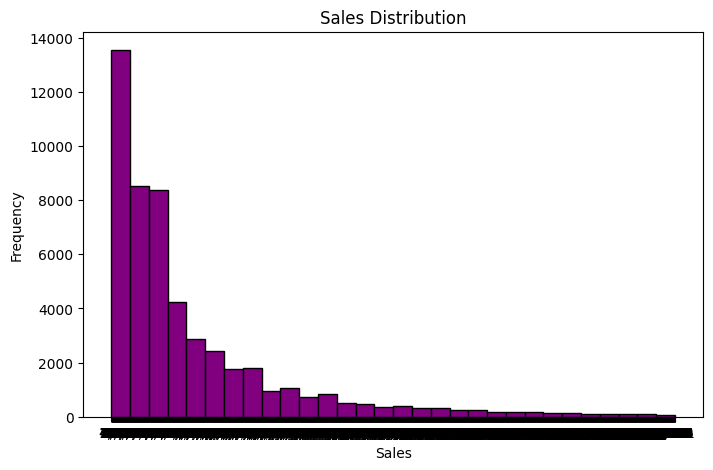

In [14]:
plt.figure(figsize=(8,5))

plt.hist(df["sales"], bins=30, color="purple", edgecolor="black")

plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

In [15]:
df["sales"] = pd.to_numeric(df["sales"], errors="coerce")

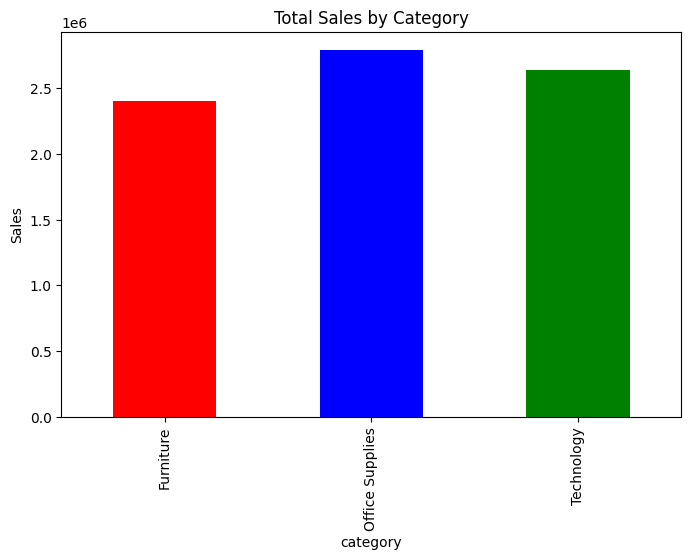

In [16]:
category_sales = df.groupby("category")["sales"].sum()

plt.figure(figsize=(8,5))

category_sales.plot(
    kind="bar",
    color=["red","blue","green"]
)

plt.title("Total Sales by Category")
plt.ylabel("Sales")

plt.show()

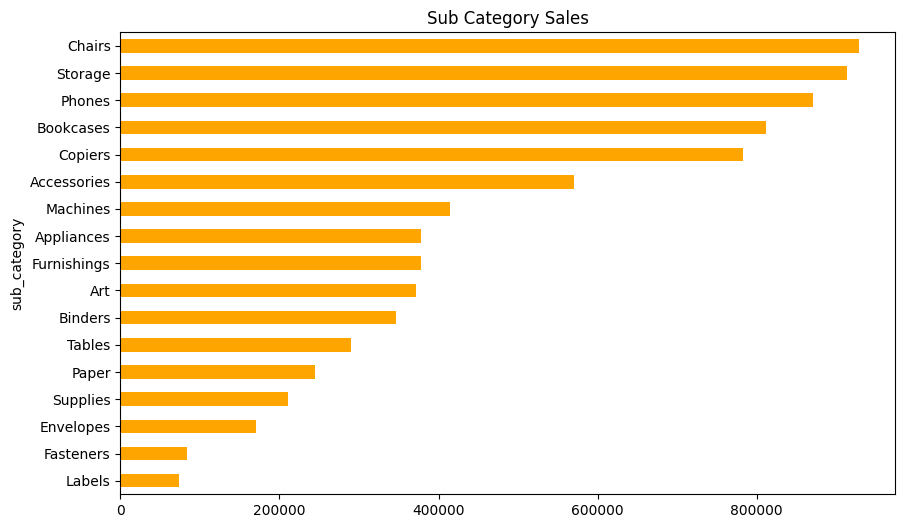

In [17]:
sub_sales = df.groupby("sub_category")["sales"].sum().sort_values()

plt.figure(figsize=(10,6))

sub_sales.plot(
    kind="barh",
    color="orange"
)

plt.title("Sub Category Sales")

plt.show()

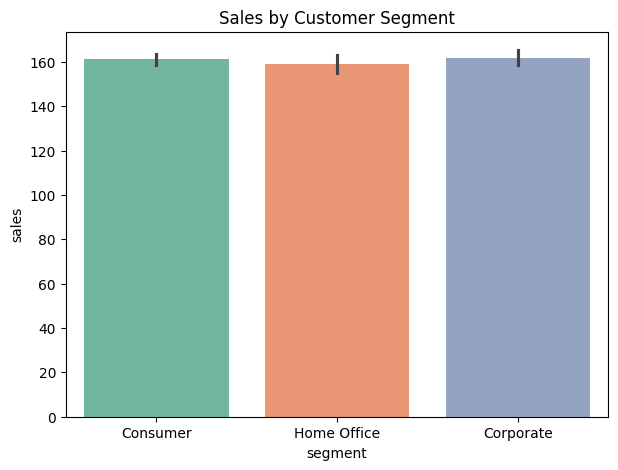

In [18]:
plt.figure(figsize=(7,5))

sns.barplot(
    x="segment",
    y="sales",
    data=df,
    palette="Set2"
)

plt.title("Sales by Customer Segment")

plt.show()

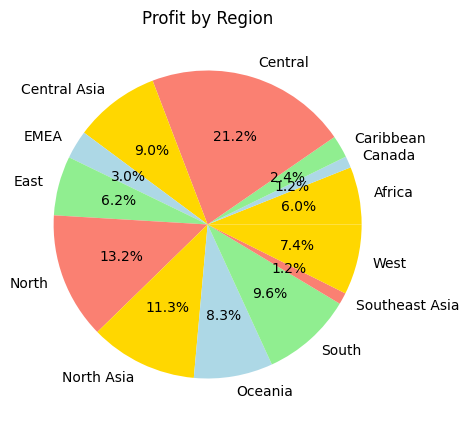

In [19]:
region_profit = df.groupby("region")["profit"].sum()

plt.figure(figsize=(7,5))

region_profit.plot(
    kind="pie",
    autopct="%1.1f%%",
    colors=["gold","lightblue","lightgreen","salmon"]
)

plt.title("Profit by Region")

plt.ylabel("")

plt.show()

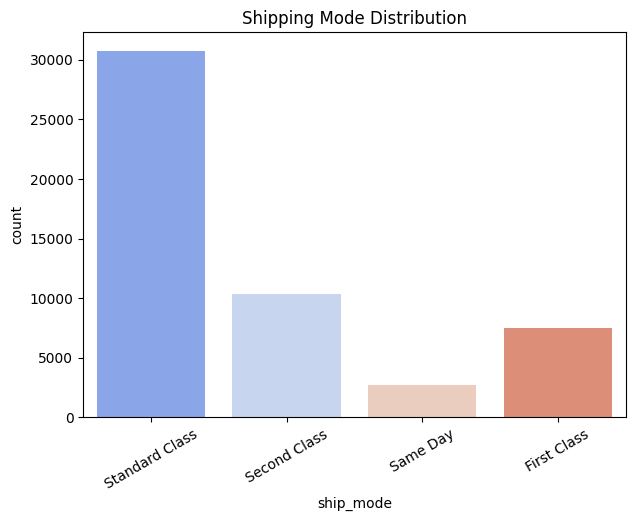

In [20]:
plt.figure(figsize=(7,5))

sns.countplot(
    x="ship_mode",
    data=df,
    palette="coolwarm"
)

plt.title("Shipping Mode Distribution")

plt.xticks(rotation=30)

plt.show()

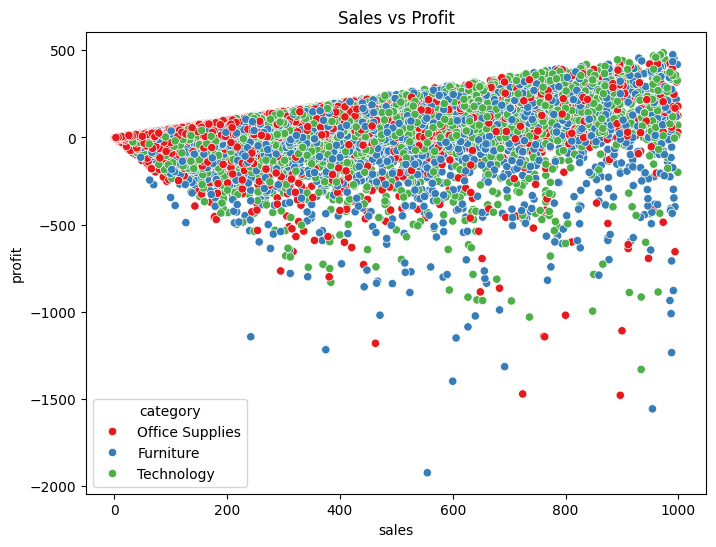

In [21]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="sales",
    y="profit",
    hue="category",
    palette="Set1",
    data=df
)

plt.title("Sales vs Profit")

plt.show()

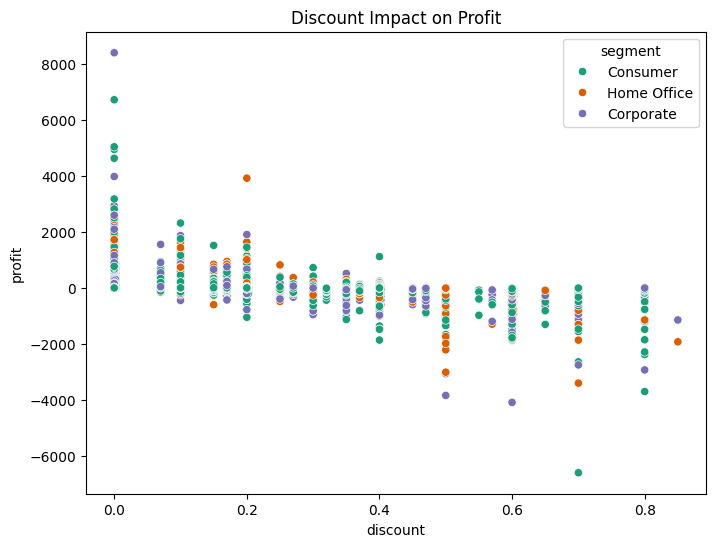

In [22]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="discount",
    y="profit",
    hue="segment",
    palette="Dark2",
    data=df
)

plt.title("Discount Impact on Profit")

plt.show()

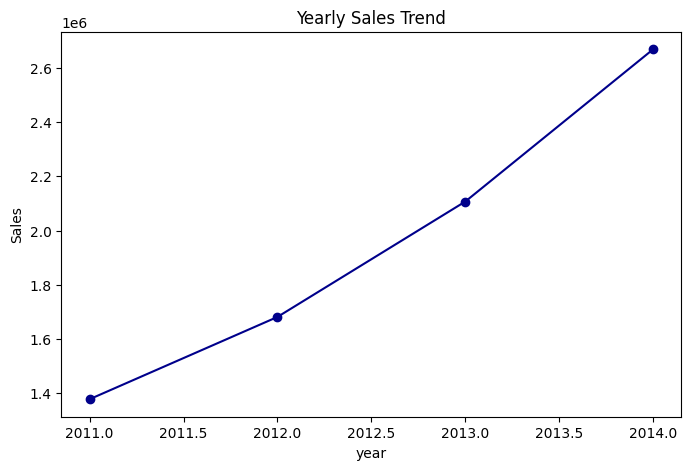

In [23]:
year_sales = df.groupby("year")["sales"].sum()

plt.figure(figsize=(8,5))

year_sales.plot(
    marker="o",
    color="darkblue"
)

plt.title("Yearly Sales Trend")

plt.ylabel("Sales")

plt.show()

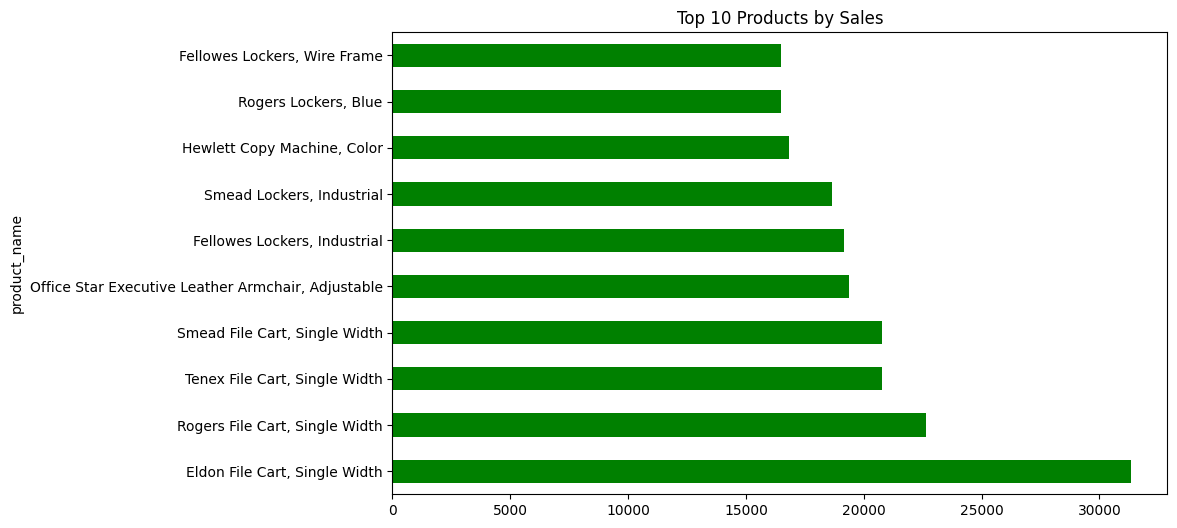

In [24]:
top_products = df.groupby("product_name")["sales"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))

top_products.plot(
    kind="barh",
    color="green"
)

plt.title("Top 10 Products by Sales")

plt.show()

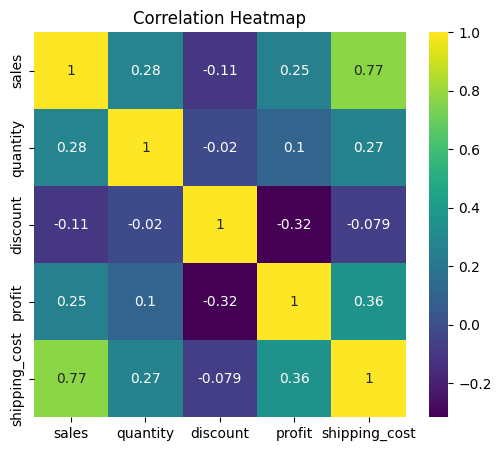

In [25]:
plt.figure(figsize=(6,5))

sns.heatmap(
    df[["sales","quantity","discount","profit","shipping_cost"]].corr(),
    annot=True,
    cmap="viridis"
)

plt.title("Correlation Heatmap")

plt.show()

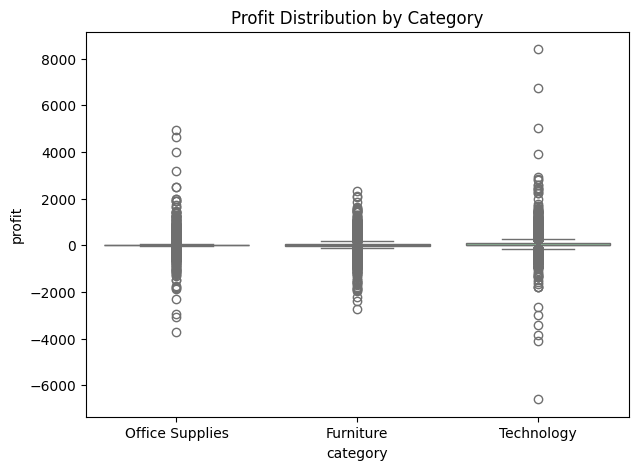

In [26]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x="category",
    y="profit",
    data=df,
    palette="pastel"
)

plt.title("Profit Distribution by Category")

plt.show()

## Feature engineering

In [27]:
# Check missing values
print(df.isnull().sum())

# Fill missing values
df.fillna(df.mean(numeric_only=True), inplace=True)

order_id             0
order_date           0
ship_date            0
ship_mode            0
customer_name        0
segment              0
state                0
country              0
market               0
region               0
product_id           0
category             0
sub_category         0
product_name         0
sales             2630
quantity             0
discount             0
profit               0
shipping_cost        0
order_priority       0
year                 0
dtype: int64


In [28]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

In [29]:
# Convert date columns
df["order_date"] = pd.to_datetime(df["order_date"], dayfirst=True)
df["ship_date"] = pd.to_datetime(df["ship_date"], dayfirst=True)

# Convert sales to numeric
df["sales"] = pd.to_numeric(df["sales"], errors="coerce")

# Handle missing values
df.fillna(df.mean(numeric_only=True), inplace=True)

In [30]:
df["order_month"] = df["order_date"].dt.month
df["order_day"] = df["order_date"].dt.day
df["ship_month"] = df["ship_date"].dt.month

# Drop original date columns
df.drop(["order_date","ship_date"], axis=1, inplace=True)

In [31]:
df.drop([
    "order_id",
    "customer_name",
    "product_id",
    "product_name"
], axis=1, inplace=True)

In [32]:
le = LabelEncoder()

categorical_cols = [
"ship_mode","segment","state","country",
"market","region","category","sub_category",
"order_priority"
]

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])


In [33]:
X = df.drop("order_priority", axis=1)
y = df["order_priority"]

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [35]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [36]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB()
}

results = {}


In [37]:
# For ROC curve (multi-class)
classes = sorted(y.unique())
n_classes = len(classes)

y_test_bin = label_binarize(y_test, classes=classes)


MODEL: Logistic Regression
Accuracy: 60.66 %


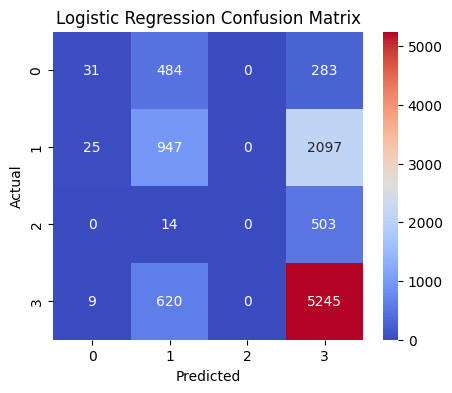

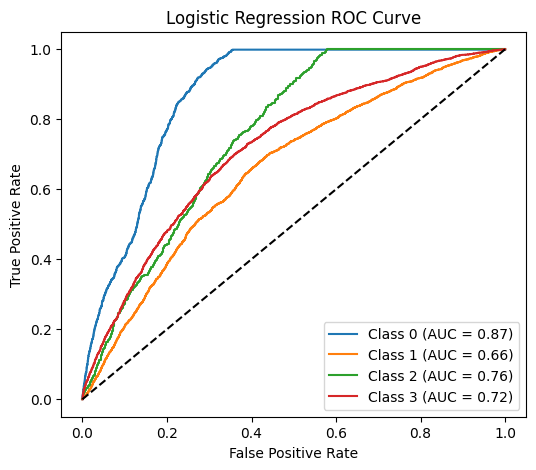


MODEL: Decision Tree
Accuracy: 61.89 %


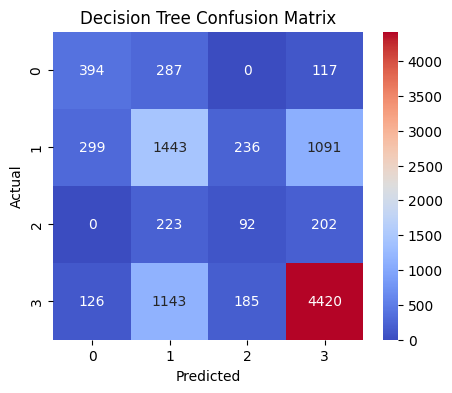

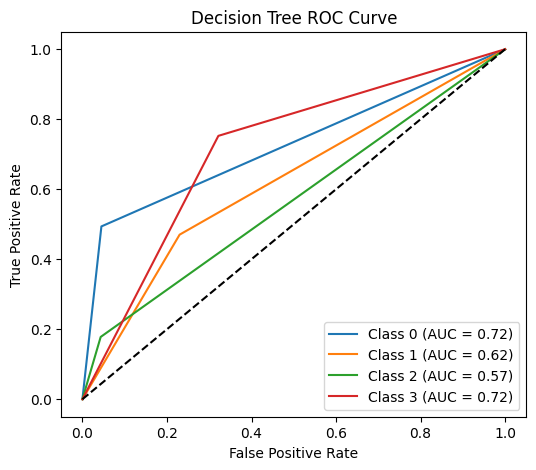


MODEL: Random Forest
Accuracy: 72.26 %


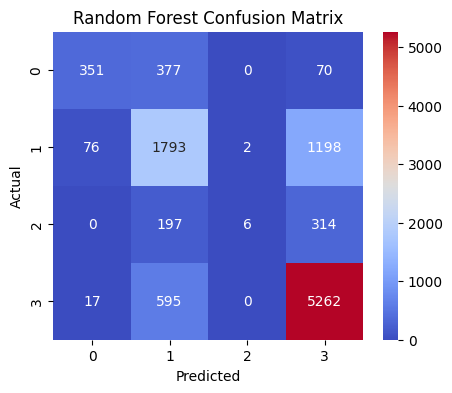

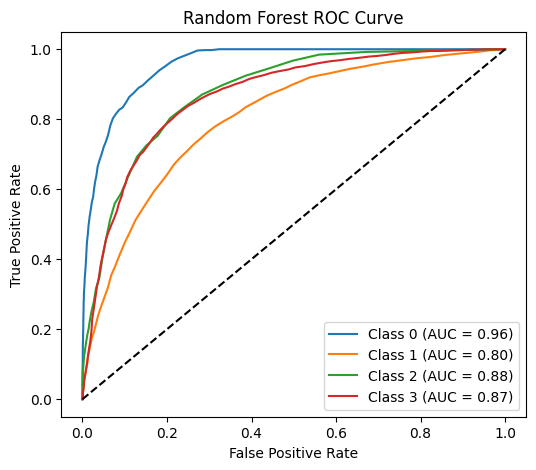


MODEL: KNN
Accuracy: 58.71 %


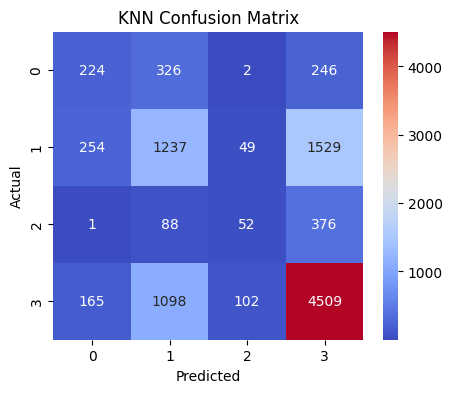

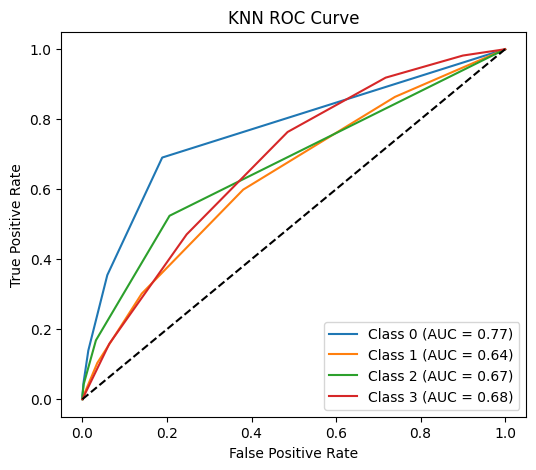


MODEL: Naive Bayes
Accuracy: 23.21 %


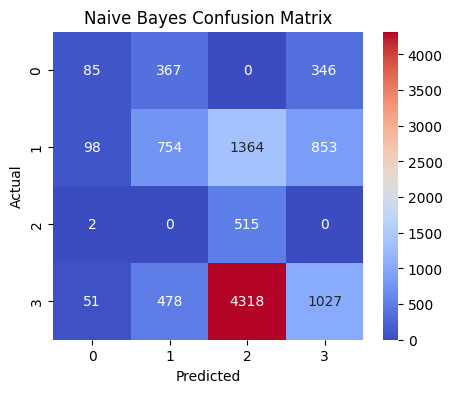

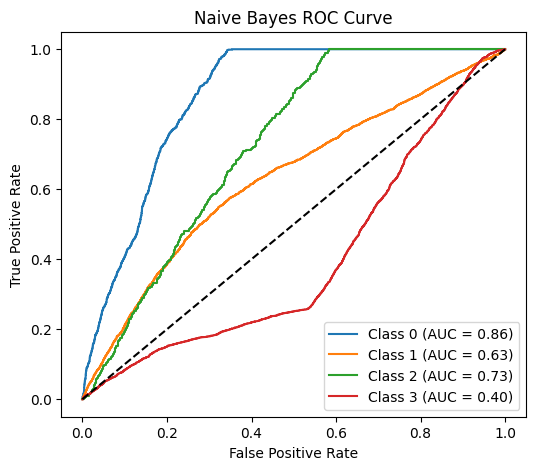


Final Accuracy Results
Logistic Regression : 60.66 %
Decision Tree : 61.89 %
Random Forest : 72.26 %
KNN : 58.71 %
Naive Bayes : 23.21 %


In [38]:
for name, model in models.items():

    print("\n" + "="*60)
    print("MODEL:", name)
    print("="*60)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    results[name] = acc * 100

    print("Accuracy:", round(acc*100,2), "%")

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="coolwarm")

    plt.title(name + " Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

    # ROC Curve
    y_prob = model.predict_proba(X_test)

    plt.figure(figsize=(6,5))

    for i in range(n_classes):

        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)

        plt.plot(fpr, tpr, label="Class %d (AUC = %.2f)" % (i, roc_auc))

    plt.plot([0,1],[0,1],'k--')

    plt.title(name + " ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")

    plt.legend()
    plt.show()

# Accuracy Comparison
print("\nFinal Accuracy Results")
print("="*40)

for model, acc in results.items():
    print(model, ":", round(acc,2), "%")

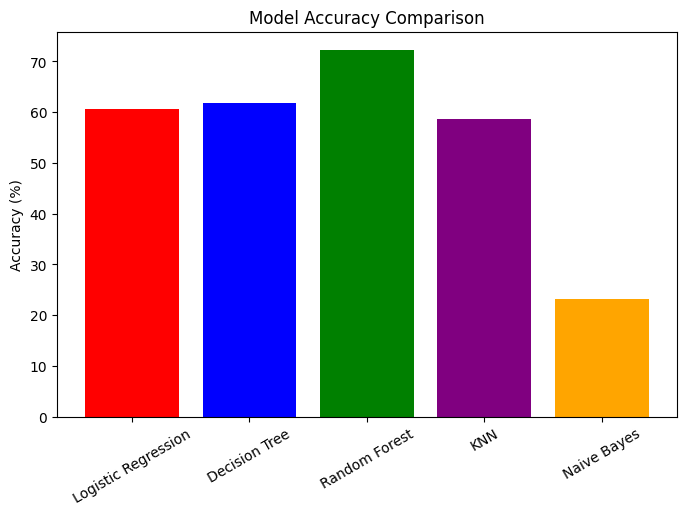

In [39]:
plt.figure(figsize=(8,5))

plt.bar(
    results.keys(),
    results.values(),
    color=["red","blue","green","purple","orange","cyan"]
)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=30)

plt.show()

## Thank you...pls upvote!!!!!!!